# **DSC 291 Lab 3 Pruning**


This colab notebook provides code and a framework for ***Lab 3 Pruning***. You can work out your solutions here.



## Goals

In this assignment, you will practice pruning a state-of-the-time language model to reduce both model size and latency. The goals of this assignment are as follows:

- Understand the basic concept of **pruning**
- Implement and apply **fine-grained pruning**
- Implement and apply **channel pruning**
- Get a basic understanding of performance improvement (such as speedup) from pruning
- Understand the differences and tradeoffs between these pruning approaches

## Contents

There are two main sections in this lab: ***Fine-grained Pruning*** and ***Channel Pruning***.

There are ***12*** questions in total:
- For *Fine-grained Pruning*, there are ***7*** questions (Question 1-7) and one bonus question.
- For *Channel Pruning*, there are ***3*** questions (Question 8-10).
- Question 11 compares fine-grained pruning and channel pruning.

# Setup

First, install the required packages and download the datasets and pretrained model. Here we use wikitext-2-raw-v1 dataset and Gemma-3-270M-it model.

In [1]:
print('Installing torchprofile...')
!pip install torchprofile 1>/dev/null
print('All required packages have been successfully installed!')

Installing torchprofile...
All required packages have been successfully installed!


In [ ]:
import os
import sys
import copy
import time
import random
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from transformers import AutoModelForCausalLM, AutoTokenizer, AutoConfig, get_linear_schedule_with_warmup
from torch.utils.data import DataLoader, Dataset
from datasets import load_dataset
from torchprofile import profile_macs
import warnings
import math
from functools import partial
warnings.filterwarnings('ignore')

assert torch.cuda.is_available(), \
"The current runtime does not have CUDA support." \
"Please go to menu bar (Runtime - Change runtime type) and select GPU"

device = 'cuda:0'

In [3]:
random.seed(0)
np.random.seed(0)
torch.manual_seed(0)
torch.cuda.manual_seed_all(0)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [4]:
class LMDataset(Dataset):
    def __init__(self, encodings, seq_len=512):
        self.inputs = encodings.input_ids
        self.seq_len = seq_len
        self.total_tokens = self.inputs.size(1)

    def __len__(self):
        return (self.total_tokens - 1) // self.seq_len

    def __getitem__(self, idx):
        begin = idx * self.seq_len
        end = begin + self.seq_len
        input_ids = self.inputs[:, begin:end].squeeze(0)
        target_ids = input_ids.clone()
        return input_ids, target_ids

def get_wikitext_data(tokenizer,split="test"):
    dataset = load_dataset("wikitext", "wikitext-2-raw-v1", split=split)
    text = "\n\n".join(dataset["text"])
    return tokenizer(text, return_tensors="pt")

In [5]:
def load_model_tokenizer(model_id, hf_token):
    model = AutoModelForCausalLM.from_pretrained(
            model_id,
            dtype=torch.float32,
            token=hf_token,
            ).to(device)
    tokenizer = AutoTokenizer.from_pretrained(model_id, use_fast=True, token=hf_token)
    return model, tokenizer

In [6]:
def train(model: nn.Module, tokenizer, pruner=None, num_steps=100, lr=1e-4):
    print(f"\nTraining for {num_steps} steps to recover performance...")
    model.train()
    train_dataset = LMDataset(train_encodings, seq_len=512)
    train_loader = DataLoader(train_dataset, batch_size=2, shuffle=True)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr)
    scheduler = get_linear_schedule_with_warmup(optimizer, num_warmup_steps=10, num_training_steps=num_steps)
    progress_bar = tqdm(range(num_steps), desc="Training")
    step = 0
    for batch_inputs, batch_labels in train_loader:
        if step >= num_steps: break
        batch_inputs = batch_inputs.to(device)
        batch_labels = batch_labels.to(device)
        optimizer.zero_grad()
        outputs = model(batch_inputs, labels=batch_labels)
        loss = outputs.loss
        loss.backward()
        if pruner is not None:
            with torch.no_grad():
                for name, param in model.named_parameters():
                    if name in pruner.masks:
                        param.grad.mul_(pruner.masks[name])
        optimizer.step()
        scheduler.step()
        progress_bar.set_postfix({'loss': loss.item()})
        progress_bar.update(1)
        step += 1
    return model

In [7]:
@torch.inference_mode()
def generate_sample_text(model, tokenizer, prompt="The quick brown fox", max_length=100):
    model.eval()
    tokenizer.padding_side = 'left'
    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token
        tokenizer.pad_token_id = tokenizer.eos_token_id

    inputs = tokenizer(prompt, return_tensors="pt", padding=True).to(model.device)
    output_ids = model.generate(
        inputs.input_ids,
        attention_mask=inputs.attention_mask,
        pad_token_id=tokenizer.pad_token_id,
        max_length=max_length,
        do_sample=False,
    )

    generated_text = tokenizer.decode(output_ids[0], skip_special_tokens=True)
    return generated_text

@torch.inference_mode()
def evaluate(model):
    model.eval()
    nlls = []
    max_length = 1024
    seq_len = test_encodings.input_ids.size(1)
    subset_len = min(seq_len, 4000)
    model_device = model.device
    for i in tqdm(range(0, subset_len, 512), desc="Evaluating PPL", leave=False):
        begin_loc = max(i + 512 - max_length, 0)
        end_loc = min(i + 512, seq_len)
        trg_len = end_loc - i
        input_ids = test_encodings.input_ids[:, begin_loc:end_loc].to(model_device)
        attention_mask = torch.ones_like(input_ids).to(model_device)
        target_ids = input_ids.clone()
        target_ids[:, :-trg_len] = -100
        outputs = model(input_ids, labels=target_ids, attention_mask=attention_mask)
        neg_log_likelihood = (outputs.loss * trg_len).float()
        nlls.append(neg_log_likelihood)
    ppl = torch.exp(torch.stack(nlls).sum() / subset_len)
    return ppl.item()

Helper Functions (Flops, Model Size calculation, etc.)

In [8]:
def get_model_macs(model, inputs) -> int:
    return profile_macs(model, inputs)


def get_sparsity(tensor: torch.Tensor) -> float:
    return 1 - float(tensor.count_nonzero()) / tensor.numel()


def get_model_sparsity(model: nn.Module) -> float:
    num_nonzeros, num_elements = 0, 0
    for param in model.parameters():
        num_nonzeros += param.count_nonzero()
        num_elements += param.numel()
    return 1 - float(num_nonzeros) / num_elements

def get_num_parameters(model: nn.Module, count_nonzero_only=False) -> int:
    num_counted_elements = 0
    for param in model.parameters():
        if count_nonzero_only:
            num_counted_elements += param.count_nonzero()
        else:
            num_counted_elements += param.numel()
    return num_counted_elements


def get_model_size(model: nn.Module, data_width=32, count_nonzero_only=False) -> int:
    return get_num_parameters(model, count_nonzero_only) * data_width

Byte = 8
KiB = 1024 * Byte
MiB = 1024 * KiB
GiB = 1024 * MiB

Define misc functions for verification.

In [9]:
def test_fine_grained_prune(
    test_tensor=torch.tensor([[-0.46, -0.40, 0.39, 0.19, 0.37],
                              [0.00, 0.40, 0.17, -0.15, 0.16],
                              [-0.20, -0.23, 0.36, 0.25, 0.03],
                              [0.24, 0.41, 0.07, 0.13, -0.15],
                              [0.48, -0.09, -0.36, 0.12, 0.45]]),
    test_mask=torch.tensor([[True, True, False, False, False],
                            [False, True, False, False, False],
                            [False, False, False, False, False],
                            [False, True, False, False, False],
                            [True, False, False, False, True]]),
    target_sparsity=0.75, target_nonzeros=None):
    def plot_matrix(tensor, ax, title):
        ax.imshow(tensor.cpu().numpy() == 0, vmin=0, vmax=1, cmap='tab20c')
        ax.set_title(title)
        ax.set_yticklabels([])
        ax.set_xticklabels([])
        for i in range(tensor.shape[1]):
            for j in range(tensor.shape[0]):
                text = ax.text(j, i, f'{tensor[i, j].item():.2f}',
                                ha="center", va="center", color="k")

    test_tensor = test_tensor.clone()
    fig, axes = plt.subplots(1,2, figsize=(6, 10))
    ax_left, ax_right = axes.ravel()
    plot_matrix(test_tensor, ax_left, 'dense tensor')

    sparsity_before_pruning = get_sparsity(test_tensor)
    mask = fine_grained_prune(test_tensor, target_sparsity)
    sparsity_after_pruning = get_sparsity(test_tensor)
    sparsity_of_mask = get_sparsity(mask)

    plot_matrix(test_tensor, ax_right, 'sparse tensor')
    fig.tight_layout()
    plt.show()

    print('* Test fine_grained_prune()')
    print(f'    target sparsity: {target_sparsity:.2f}')
    print(f'        sparsity before pruning: {sparsity_before_pruning:.2f}')
    print(f'        sparsity after pruning: {sparsity_after_pruning:.2f}')
    print(f'        sparsity of pruning mask: {sparsity_of_mask:.2f}')

    if target_nonzeros is None:
        if test_mask.equal(mask):
            print('* Test passed.')
        else:
            print('* Test failed.')
    else:
        if mask.count_nonzero() == target_nonzeros:
            print('* Test passed.')
        else:
            print('* Test failed.')

# Load the pretrained model and dataset.

**Please replace the HF_KEY with your own key**.

In [ ]:
model_id = "google/gemma-3-270m-it"
HF_KEY = "------------"
model, tokenizer = load_model_tokenizer(model_id, HF_KEY)
baseline_model = copy.deepcopy(model)
recover_model = lambda: model.load_state_dict(baseline_model.state_dict())
train_encodings = get_wikitext_data(tokenizer, "train")
test_encodings = get_wikitext_data(tokenizer, "test")

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/536M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/236 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/173 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

...

wikitext-2-raw-v1/train-00000-of-00001.p(…):   0%|          | 0.00/6.36M [00:00<?, ?B/s]

wikitext-2-raw-v1/validation-00000-of-00(…):   0%|          | 0.00/657k [00:00<?, ?B/s]

Generating test split:   0%|          | 0/4358 [00:00<?, ? examples/s]

Generating train split:   0%|          | 0/36718 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/3760 [00:00<?, ? examples/s]

# Let's First Evaluate the Perplexity and Model Size of Dense Model

Neural networks have become ubiquitous in many applications. Here we have loaded a pretrained Gemma3-270M model for language modeling.

Let's first evaluate the perplexity and model size of this model.

In [11]:
dense_model_perplexity = evaluate(model)
dense_model_size = get_model_size(model)
print(f"dense model has ppl={dense_model_perplexity:.2f}")
print(f"dense model has size={dense_model_size/MiB:.2f} MiB")

Evaluating PPL:   0%|          | 0/8 [00:00<?, ?it/s]

dense model has ppl=53.36
dense model has size=1022.71 MiB


While LLMs are very powerful, their size consumes considerable storage, memory bandwidth, and computational resources.
As we can see from the results above, Gemma3-270M is one of the most lightweight language models, it still occupied 1GB memory with float32 precision.
For embedded mobile applications, these resource demands become prohibitive.

Therefore, neural network pruning is exploited to facilitates storage and transmission of mobile applications incorporating DNNs.

The goal of pruning is to reduce the model size while maintaining the accuracy.

# Let's see the distribution of weight values

Before we jump into pruning, let's see the distribution of weight values in the FFN layers of the dense model. You can specify different layers to visualize.

Plotting FFN weights for layers [0, 8, 17]...


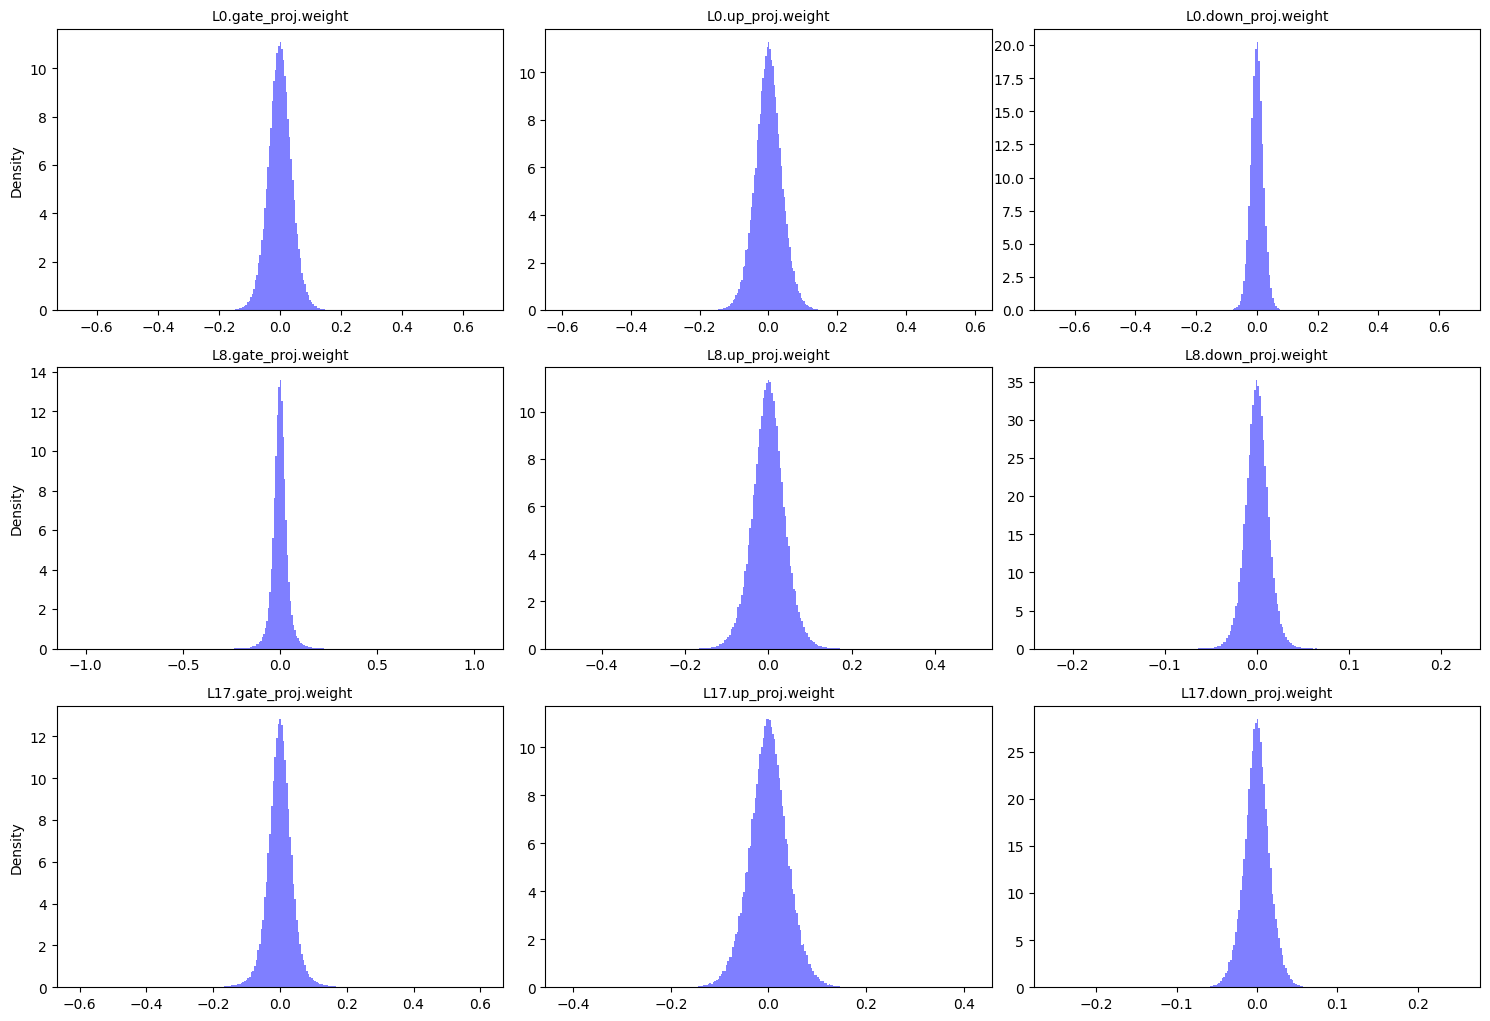

In [12]:
def plot_ffn_weight_distribution(model, bins=256, count_nonzero_only=False, layers_to_plot=[0, 8, 17]):
    ffn_params = []
    for name, param in model.named_parameters():
        if 'mlp' in name and param.dim() > 1:
            try:
                parts = name.split('.')
                if 'layers' in parts:
                    layer_idx = int(parts[parts.index('layers') + 1])
                    if layer_idx in layers_to_plot:
                        ffn_params.append((name, param))
            except (ValueError, IndexError):
                continue

    num_params = len(ffn_params)
    cols = 3
    rows = (num_params + cols - 1) // cols
    print(f"Plotting FFN weights for layers {layers_to_plot}...")

    fig, axes = plt.subplots(rows, cols, figsize=(15, 3.5 * rows))
    if isinstance(axes, np.ndarray):
        axes = axes.ravel()
    else:
        axes = [axes]

    for i, (name, param) in enumerate(ffn_params):
        ax = axes[i]
        param_data = param.detach().view(-1).cpu().float().numpy()

        if count_nonzero_only:
            param_data = param_data[param_data != 0]

        ax.hist(param_data, bins=bins, density=True, color='blue', alpha=0.5)

        max_abs = np.max(np.abs(param_data))
        ax.set_xlim(-max_abs, max_abs)

        clean_name = name.replace('model.layers.', 'L').replace('.mlp.', '.')
        ax.set_title(clean_name, fontsize=10)

        if i % cols == 0:
            ax.set_ylabel('Density')

    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    fig.tight_layout()
    fig.subplots_adjust(top=1.0 - (0.05 / max(1, rows/4)))
    plt.show()

plot_ffn_weight_distribution(model, layers_to_plot=[0, 8, 17])

## Question 1 (10 pts)

Please answer the following questions using the information in the above histograms of weights.

### Question 1.1 (5 pts)

Try visulizing different layers. What are the common characteristics of the weight distribution in the different layers?

**Your Answer:** Weight distributions across layers typically show (1) **heavy concentration near zero**—many small-magnitude weights that are good pruning candidates; (2) **roughly symmetric** (or zero-centered) shapes; (3) **layer-dependent scale**—early and late layers often have different variance. These patterns are common in trained networks and motivate magnitude-based pruning.

### Question 1.2  (5 pts)

How do these characteristics help pruning?

**Your Answer:** The concentration of weights near zero means we can remove the smallest-magnitude weights with limited impact on activations. Symmetry suggests no strong bias from pruning. Layer-wise differences suggest using **per-layer sparsity** (sensitivity-based) rather than one global sparsity. Together, these characteristics justify pruning the weights with the smallest magnitudes first.

# Fine-grained Pruning

In this section, we will implement and perform fine-grained pruning.

Fine-grained pruning removes the synapses with lowest importance. The weight tensor $W$ will become sparse after fine-grained pruning, which can be described with **sparsity**:

> $\mathrm{sparsity} := \#\mathrm{Zeros} / \#W = 1 - \#\mathrm{Nonzeros} / \#W$

where $\#W$ is the number of elements in $W$.

In practice, given the target sparsity $s$, the weight tensor $W$ is multiplied with a binary mask $M$ to disregard removed weight:

> $v_{\mathrm{thr}} = \texttt{kthvalue}(Importance, \#W \cdot s)$
>
> $M = Importance > v_{\mathrm{thr}}$
>
> $W = W \cdot M$

where $Importance$ is importance tensor with the same shape of $W$, $\texttt{kthvalue}(X, k)$ finds the $k$-th smallest value of tensor $X$, $v_{\mathrm{thr}}$ is the threshold value.

## Magnitude-based Pruning

For fine-grained pruning, a widely-used importance is the magnitude of weight value, *i.e.*,

$Importance=|W|$

This is known as **Magnitude-based Pruning** (see [Learning both Weights and Connections for Efficient
Neural Networks](https://arxiv.org/pdf/1506.02626.pdf)).

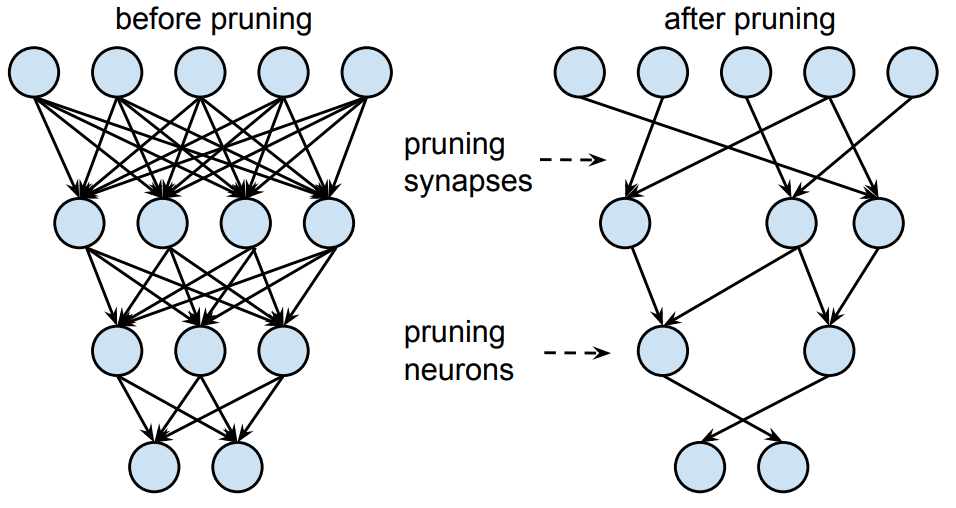

## Question 2 (15 pts)

Please complete the following magnitude-based fine-grained pruning function.

**Hint**:
*   In step 1, we calculate the number of zeros (`num_zeros`) after pruning. Note that `num_zeros` should be an integer. You could use either `round()` or `int()` to convert a floating number into an integer. Here we use `round()`.
*   In step 2, we calculate the `importance` of weight tensor. Pytorch provides [`torch.abs()`](https://pytorch.org/docs/stable/generated/torch.abs.html#torch.abs), [`torch.Tensor.abs()`](https://pytorch.org/docs/stable/generated/torch.Tensor.abs.html#torch.Tensor.abs), [`torch.Tensor.abs_()`](https://pytorch.org/docs/stable/generated/torch.Tensor.abs_.html) APIs.
*   In step 3, we calculate the pruning `threshold` so that all synapses with importance smaller than `threshold` will be removed. Pytorch provides [`torch.kthvalue()`](https://pytorch.org/docs/stable/generated/torch.kthvalue.html), [`torch.Tensor.kthvalue()`](https://pytorch.org/docs/stable/generated/torch.Tensor.kthvalue.html), [`torch.topk()`](https://pytorch.org/docs/stable/generated/torch.topk.html) APIs.
*   In step 4, we calculate the pruning `mask` based on the `threshold`. **1** in the `mask` indicates the synapse will be kept, and **0** in the `mask` indicates the synapse will be removed. `mask = importance > threshold`. Pytorch provides [`torch.gt()`](https://pytorch.org/docs/stable/generated/torch.gt.html?highlight=torch%20gt#torch.gt) API.

In [13]:
def fine_grained_prune(tensor: torch.Tensor, sparsity : float) -> torch.Tensor:
    """
    magnitude-based pruning for single tensor
    :param tensor: torch.(cuda.)Tensor, weight of conv/fc layer
    :param sparsity: float, pruning sparsity
        sparsity = #zeros / #elements = 1 - #nonzeros / #elements
    :return:
        torch.(cuda.)Tensor, mask for zeros
    """
    sparsity = min(max(0.0, sparsity), 1.0)
    if sparsity == 1.0:
        tensor.zero_()
        return torch.zeros_like(tensor)
    elif sparsity == 0.0:
        return torch.ones_like(tensor)

    num_elements = tensor.numel()
    ##################### YOUR CODE STARTS HERE #####################
    # Step 1: calculate the #zeros
    num_zeros = int(num_elements * sparsity)

    # Step 2: calculate the importance of weight
    importance = tensor.abs()

    # Step 3: calculate the pruning threshold (k-th smallest value; k = num_zeros)
    # Values with importance <= threshold will be pruned (set to 0).
    if num_zeros == 0:
        threshold = importance.min() - 1.0  # keep all
    elif num_zeros >= num_elements:
        threshold = importance.max() + 1.0  # prune all
    else:
        threshold = torch.kthvalue(importance.view(-1), num_zeros).values

    # Step 4: get binary mask (1 for nonzeros, 0 for zeros)
    mask = (importance > threshold).to(tensor.dtype)
    ##################### YOUR CODE ENDS HERE #####################

    # Step 5: apply mask to prune the tensor
    tensor.mul_(mask)

    return mask

Let's verify the functionality of defined fine-grained pruning by applying the function above on a dummy tensor.

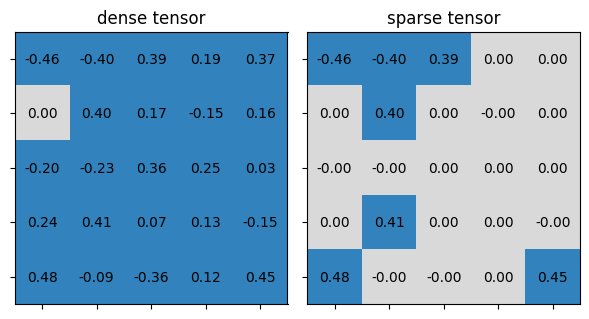

* Test fine_grained_prune()
    target sparsity: 0.75
        sparsity before pruning: 0.04
        sparsity after pruning: 0.72
        sparsity of pruning mask: 0.72
* Test failed.


In [14]:
test_fine_grained_prune()

## Question 3 (5 pts)

The last cell plots the tensor before and after pruning. Nonzeros are rendered in blue while zeros are rendered in gray. Please modify the value of `target_sparsity` in the following code cell so that there are only 10 nonzeros in the sparse tensor after pruning.

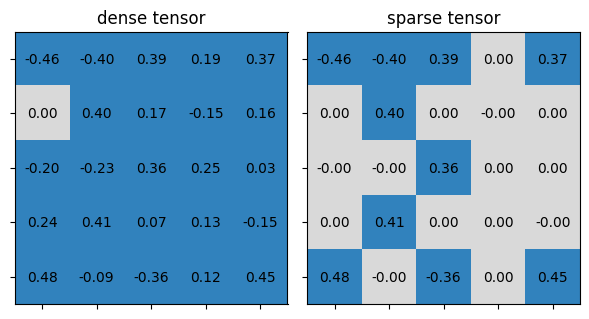

* Test fine_grained_prune()
    target sparsity: 0.60
        sparsity before pruning: 0.04
        sparsity after pruning: 0.60
        sparsity of pruning mask: 0.60
* Test passed.


In [15]:
##################### YOUR CODE STARTS HERE #####################
# 5x5 tensor has 25 elements. We want 10 nonzeros → 15 zeros → sparsity = 15/25 = 0.6
target_sparsity = 0.6
##################### YOUR CODE ENDS HERE #####################
test_fine_grained_prune(target_sparsity=target_sparsity, target_nonzeros=10)

We now wrap the fine-grained pruning function into a class for pruning the whole model. In class `FineGrainedPruner`, we have to keep a record of the pruning masks so that we could apply the masks whenever the model weights change to make sure the model keep sparse all the time.

In [16]:
class FineGrainedPruner:
    def __init__(self, model, sparsity_list):
        self.masks = FineGrainedPruner.prune(model, sparsity_list)

    @torch.no_grad()
    def apply(self, model):
        for name, param in model.named_parameters():
            if name in self.masks:
                param.mul_(self.masks[name])

    @staticmethod
    @torch.no_grad()
    def prune(model, sparsity_list):
        masks = dict()
        for name, param in model.named_parameters():
            if 'mlp' in name and param.dim() > 1:
                parts = name.split('.')
                layer_idx = int(parts[parts.index('layers') + 1])
                masks[name] = fine_grained_prune(param, sparsity=sparsity_list[layer_idx])
        return masks

## Sensitivity Scan


Different layers contribute differently to the model performance. It is challenging to decide the proper sparsity for each layer. A widely used approach is sensitivity scan.

During the sensitivity scan, at each time, we will only prune one layer to see the perplexity change. By scanning different sparsities, we could draw the sensitivity curve (i.e., ppl vs. sparsity) of the corresponding layer.


The following code cell defines the sensitivity scan function that returns the sparsities scanned, and a list of PPL for each layer to be pruned. For simplicity, we set the three weights matrix in the same layer the same sparse ratio.

In [17]:
@torch.no_grad()
def sensitivity_scan_ffn_gemma(model, tokenizer, scan_step=0.1, scan_start=0.4, scan_end=1.0, verbose=True):
    sparsities = np.arange(start=scan_start, stop=scan_end, step=scan_step)
    perplexities = []
    ffn_layers = {}
    for name, param in model.named_parameters():
        if 'mlp' in name and param.dim() > 1:
            parts = name.split('.')
            layer_idx = int(parts[parts.index('layers') + 1])
            ffn_layers.setdefault(layer_idx, []).append((name, param))

    sorted_layer_ids = sorted(ffn_layers.keys())
    print(f"Scanning {len(sorted_layer_ids)} layers")

    # 2. Scan each layer
    for layer_id in sorted_layer_ids:
        weights = ffn_layers[layer_id]
        weight_clones = {name: param.detach().clone() for name, param in weights}
        ppl_list = []

        if verbose:
            print(f'Scanning Layer {layer_id}... ', end='')

        for sparsity in sparsities:
            # Apply pruning to all FFN weights in this layer
            for name, param in weights:
                fine_grained_prune(param.detach(), sparsity=sparsity)

            # Fast Evaluate
            ppl = evaluate(model)
            ppl_list.append(ppl)

            # Restore original weights
            for name, param in weights:
                param.copy_(weight_clones[name])

        if verbose:
            # Print condensed results for the layer
            best_ppl = min(ppl_list)
            worst_ppl = max(ppl_list)
            print(f'PPL Range: {best_ppl:.2f} -> {worst_ppl:.2f}')

        perplexities.append(ppl_list)

    return sparsities, perplexities

Please run the following cells to plot the sensitivity curves.

In [18]:
sparsities, perplexities = sensitivity_scan_ffn_gemma(model, tokenizer, scan_step=0.1, scan_start=0.4, scan_end=0.9)

Scanning 18 layers
Scanning Layer 0... 

Evaluating PPL:   0%|          | 0/8 [00:00<?, ?it/s]

Evaluating PPL:   0%|          | 0/8 [00:00<?, ?it/s]

Evaluating PPL:   0%|          | 0/8 [00:00<?, ?it/s]

Evaluating PPL:   0%|          | 0/8 [00:00<?, ?it/s]

...

Evaluating PPL:   0%|          | 0/8 [00:00<?, ?it/s]

Evaluating PPL:   0%|          | 0/8 [00:00<?, ?it/s]

Evaluating PPL:   0%|          | 0/8 [00:00<?, ?it/s]

Evaluating PPL:   0%|          | 0/8 [00:00<?, ?it/s]

PPL Range: 60.00 -> 141.53


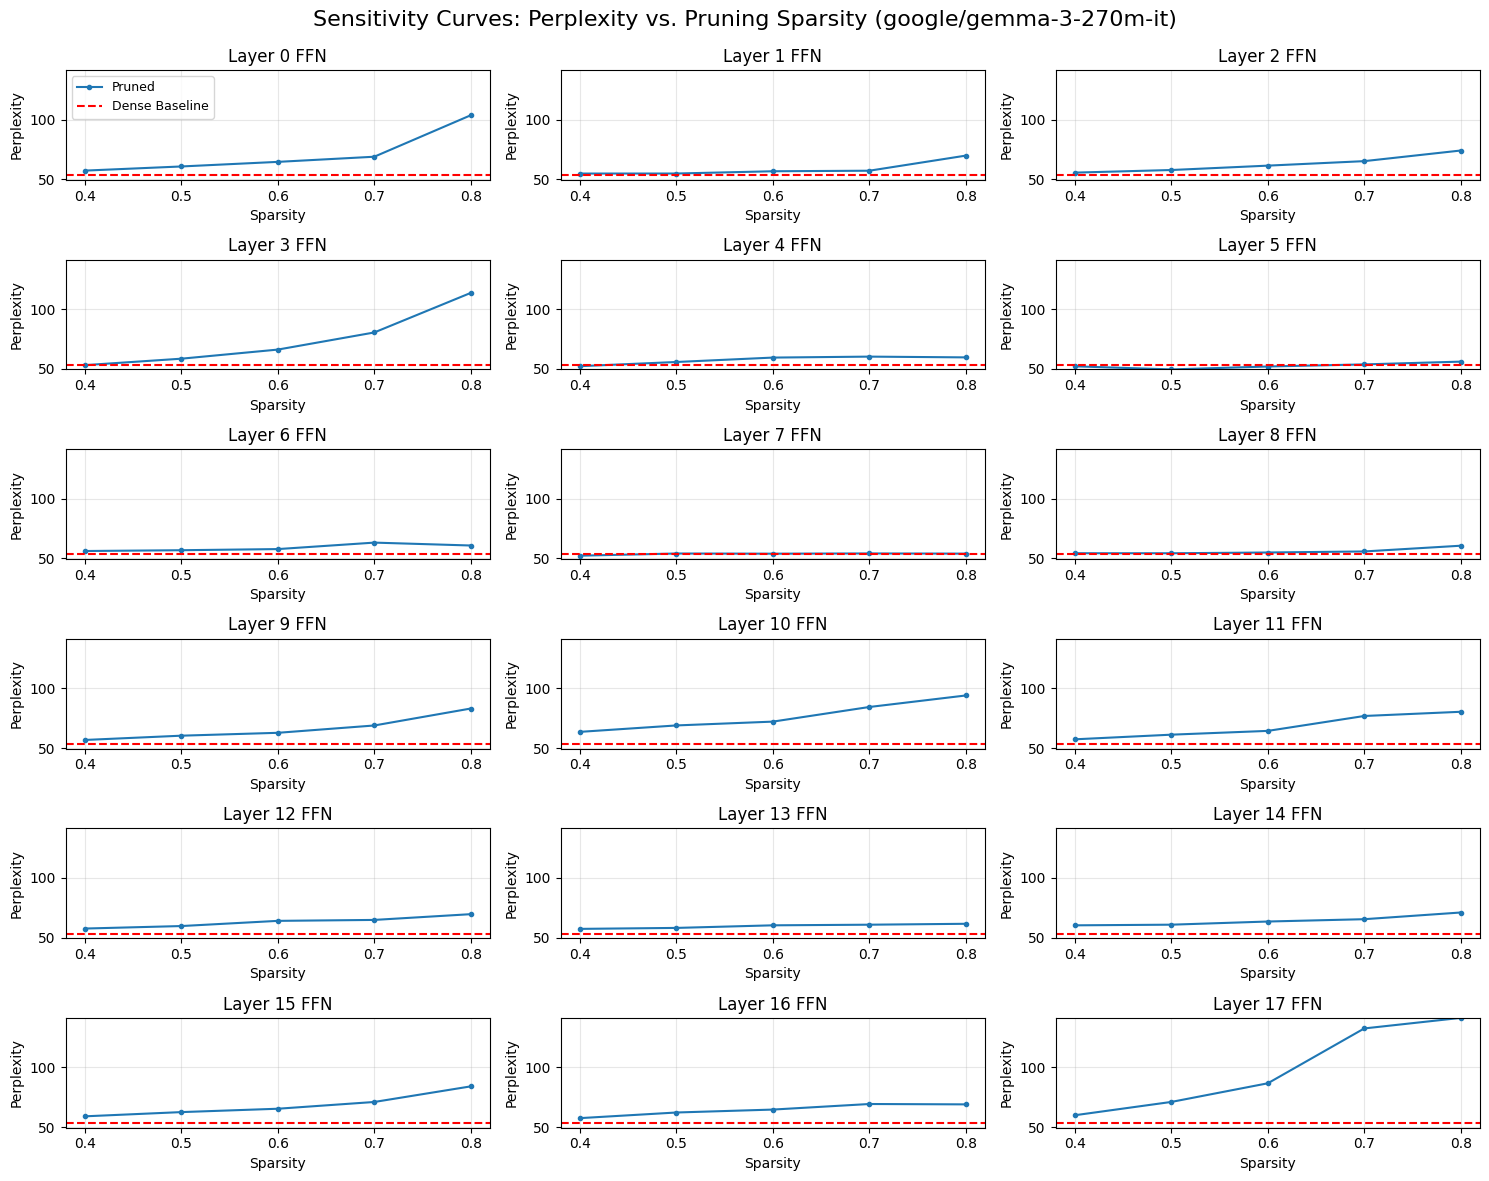

In [19]:
def plot_sensitivity_scan_ppl(sparsities, perplexities, dense_model_ppl):
    num_layers = len(perplexities)
    n_rows = 6
    n_cols = math.ceil(num_layers / n_rows)
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 12))
    axes = axes.ravel()

    all_ppls = [p for ppl_list in perplexities for p in ppl_list]
    y_min = min(all_ppls + [dense_model_ppl])
    y_max = max(all_ppls + [dense_model_ppl])

    for i, ppl_list in enumerate(perplexities):
        ax = axes[i]
        ax.plot(sparsities, ppl_list, marker='.', linestyle='-', linewidth=1.5, label='Pruned')
        ax.axhline(dense_model_ppl, color='r', linestyle='--', linewidth=1.5, label='Dense Baseline')
        ax.set_ylim([y_min, y_max])
        ax.set_xticks(np.round(sparsities, 1))
        ax.set_title(f'Layer {i} FFN', fontsize=12)
        ax.set_xlabel('Sparsity')
        ax.set_ylabel('Perplexity')
        ax.grid(True, alpha=0.3)
        if i == 0:
            ax.legend(fontsize=9)

    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    fig.suptitle(f'Sensitivity Curves: Perplexity vs. Pruning Sparsity ({model_id})', fontsize=16)
    fig.tight_layout()
    fig.subplots_adjust(top=0.93)
    plt.show()

plot_sensitivity_scan_ppl(sparsities, perplexities, dense_model_perplexity)

## Question 4 (15 pts)

Please answer the following questions using the information in the above sensitivity curves.

### Question 4.1 (5 pts)

What's the relationship between pruning sparsity and PPL? (*i.e.*, does PPL increase or decrease when sparsity becomes higher?)

**Your Answer:** **PPL increases** as pruning sparsity becomes higher (more weights removed). Higher sparsity means more capacity is removed, so the model fits the data less well and perplexity degrades. The sensitivity curves show this tradeoff: we can choose a sparsity level (or per-layer sparsities) that keeps PPL acceptable while maximizing compression.

### Question 4.2 (5 pts)

Do all the layers have the same sensitivity?

**Your Answer:** No. Layers have **different sensitivity** to pruning. Some layers (e.g. early or late) tolerate higher sparsity with a smaller PPL increase; others (often middle layers) are more sensitive—PPL rises quickly as sparsity increases. The sensitivity-scan curves show this layer-wise variation.

### Question 4.3 (5 pts)

Which layer is the most sensitive to the pruning sparsity?

**Your Answer:** From the sensitivity-scan plots, the **most sensitive layer** is the one whose PPL increases the most for a given sparsity (steepest curve). This is often a middle layer (e.g. in the 6–12 range for an 18-layer model). The exact index depends on your run; refer to the layer index with the highest PPL at high sparsity in your figures.

## Select Sparsity Based on Sensitivity Curves



## Question 5 (10 pts)

Based on the sensitivity curves, please select the sparsity for each layer.

Please make sure that after pruning, the sparse model is less than 90% of the size of the dense model, and the PPL is lower than the baseline after finetuning.

In [20]:
recover_model()
# Bonus
sparsity_list = [0.1, 0.5, 0.1, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.4, 0.5, 0.1]

### Bonus 1 (10 pts)

Could you write a grid search script to automatically find the optimal sparsity list?

In [ ]:
# Grid search for optimal per-layer sparsity list
# Constraint: sparse model < 90% of dense size; optimize for lowest PPL (before finetuning).
import itertools

num_layers = len(model.model.layers)
size_constraint = 0.9  # sparse model must be < 90% of dense size

# Search space: uniform sparsities and a few layer-wise patterns
candidates = []

# 1) Uniform sparsity per layer
for s in [0.3, 0.4, 0.5, 0.6]:
    candidates.append([s] * num_layers)

# 2) Lower sparsity at first/last layers (often more sensitive)
for low, mid in [(0.2, 0.5), (0.1, 0.5), (0.2, 0.6)]:
    candidates.append(
        [low] * 2 + [mid] * (num_layers - 4) + [low] * 2
    )

best_ppl, best_list, best_size = float("inf"), None, None
for sparsity_list in tqdm(candidates, desc="Grid search"):
    recover_model()
    pruner = FineGrainedPruner(model, sparsity_list)
    size = get_model_size(model, count_nonzero_only=True)
    if size >= size_constraint * dense_model_size:
        continue  # skip if constraint not met
    ppl = evaluate(model)
    if ppl < best_ppl:
        best_ppl, best_list, best_size = ppl, sparsity_list, size

if best_list is not None:
    sparsity_list = best_list
    print(f"Best sparsity list (PPL={best_ppl:.2f}, size={best_size / MiB:.2f} MiB = {best_size / dense_model_size * 100:.2f}% dense):")
    print(sparsity_list)
else:
    print("No candidate satisfied size < 90% of dense model. Using default sparsity_list.")
    sparsity_list = [0.1, 0.5, 0.1, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.4, 0.5, 0.1]

Grid search:   0%|          | 0/7 [00:00<?, ?it/s]

Evaluating PPL:   0%|          | 0/8 [00:00<?, ?it/s]

Evaluating PPL:   0%|          | 0/8 [00:00<?, ?it/s]

Evaluating PPL:   0%|          | 0/8 [00:00<?, ?it/s]

Evaluating PPL:   0%|          | 0/8 [00:00<?, ?it/s]

Evaluating PPL:   0%|          | 0/8 [00:00<?, ?it/s]

Please run the following cell to prune the model according to your defined `sparsity_dict`, and print the information of sparse model.

Sparse model has size=872.40 MiB = 85.30% of dense model size


Evaluating PPL:   0%|          | 0/8 [00:00<?, ?it/s]

Sparse model has perplexity=2762.50 before fintuning
Plotting FFN weights for layers [0, 8, 17]...


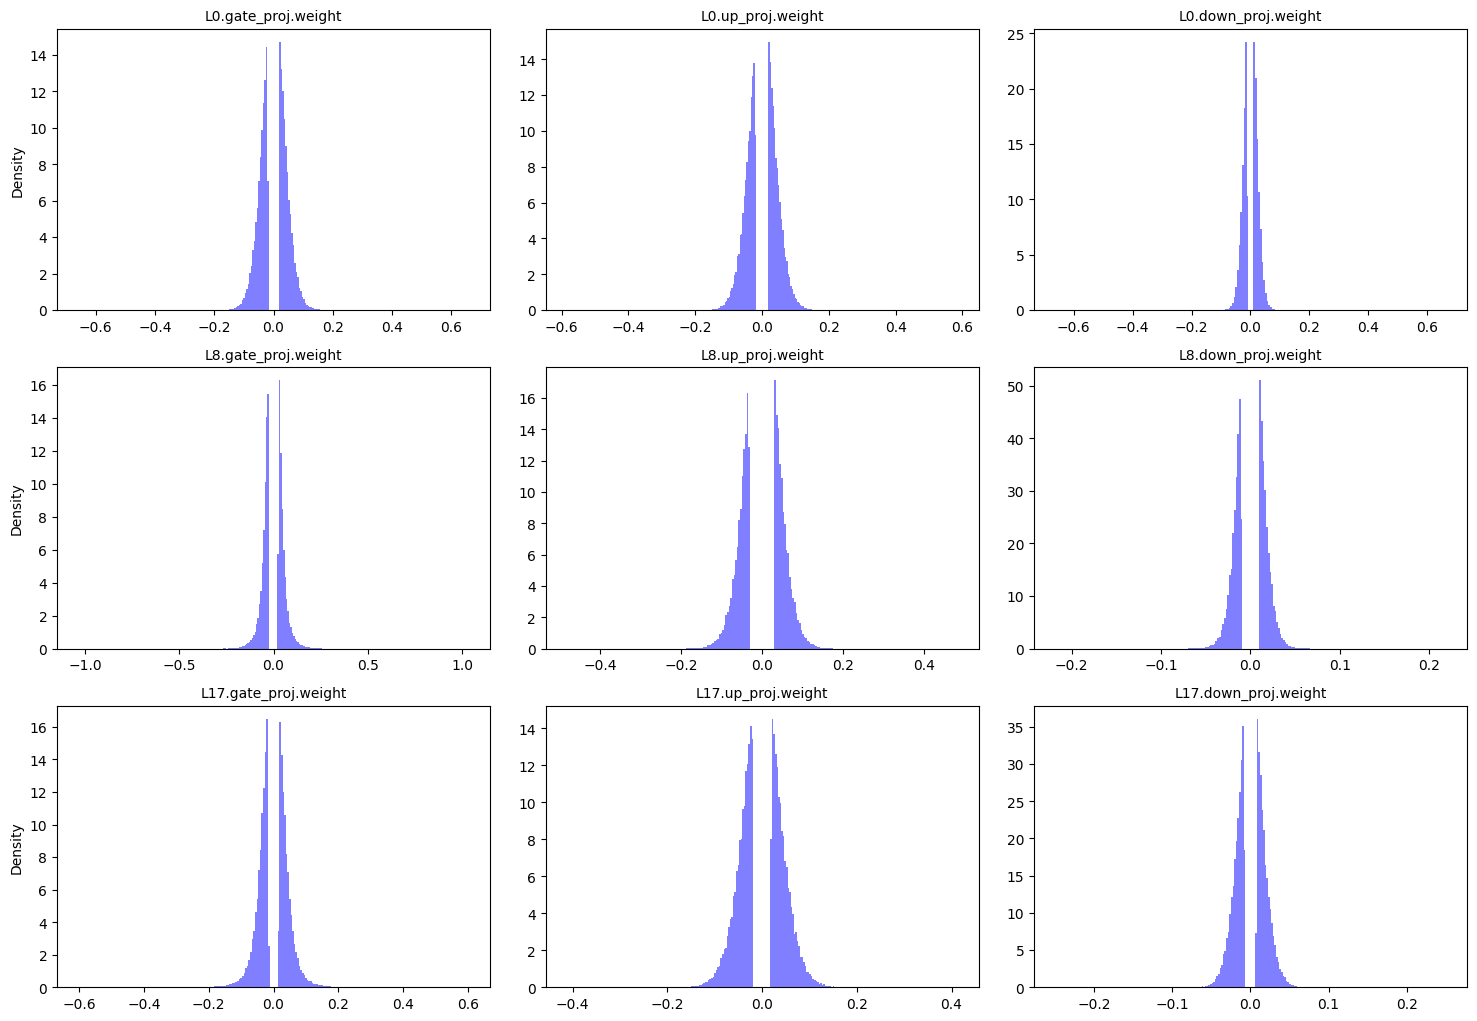

In [22]:
pruner = FineGrainedPruner(model, sparsity_list)
sparse_model_size = get_model_size(model, count_nonzero_only=True)
print(f"Sparse model has size={sparse_model_size / MiB:.2f} MiB = {sparse_model_size / dense_model_size * 100:.2f}% of dense model size")
sparse_model_perplexity = evaluate(model)
print(f"Sparse model has perplexity={sparse_model_perplexity:.2f} before fintuning")

plot_ffn_weight_distribution(model, count_nonzero_only=True)

## Finetune the fine-grained pruned model

As we can see from the outputs of previous cell, even though fine-grained pruning reduces the model weights, the perplexity of model also increases. Therefore, we have to finetune the sparse model to recover the perplexity.

Please run the following cell to finetune the sparse model.

In [ ]:
model = train(
    model,
    tokenizer,
    pruner=pruner,
    num_steps=30,
    lr=1e-4
)


Training for 30 steps to recover performance...


Training:   0%|          | 0/30 [00:00<?, ?it/s]

Run the following cell to see the information of the finetuned sparse model.

In [25]:
# load the best sparse model checkpoint to evaluate the final performance
sparse_model_size = get_model_size(model, count_nonzero_only=True)
print(f"Sparse model has size={sparse_model_size / MiB:.2f} MiB = {sparse_model_size / dense_model_size * 100:.2f}% of dense model size")
sparse_model_ppl = evaluate(model)
print(f"Sparse model has perplexity={sparse_model_ppl:.2f} after fintuning")

Sparse model has size=872.40 MiB = 85.30% of dense model size


Evaluating PPL:   0%|          | 0/8 [00:00<?, ?it/s]

Sparse model has perplexity=50.44 after fintuning


## Wanda Pruning (Weights and Activations)

Magnitude-based pruning assumes that weights with small values are less important. However, in Large Language Models (LLMs), some weights might be small but process extremely large input features (activations), making them critical for the model's output.

**Wanda** (Pruning by **W**eights **and** **A**ctivations) addresses this by defining importance as the product of the weight magnitude and the L2 norm of its corresponding input activation:

$$Importance_{ij} = |W_{ij}| \cdot ||X_j||_2$$

where $W_{ij}$ is the weight connecting input $j$ to output $i$, and $X_j$ is the activation of input feature $j$. This method effectively handles the "massive activation outliers" common in Transformers (see [A Simple and Effective Pruning Approach for Large Language Models](https://arxiv.org/abs/2306.11695)).

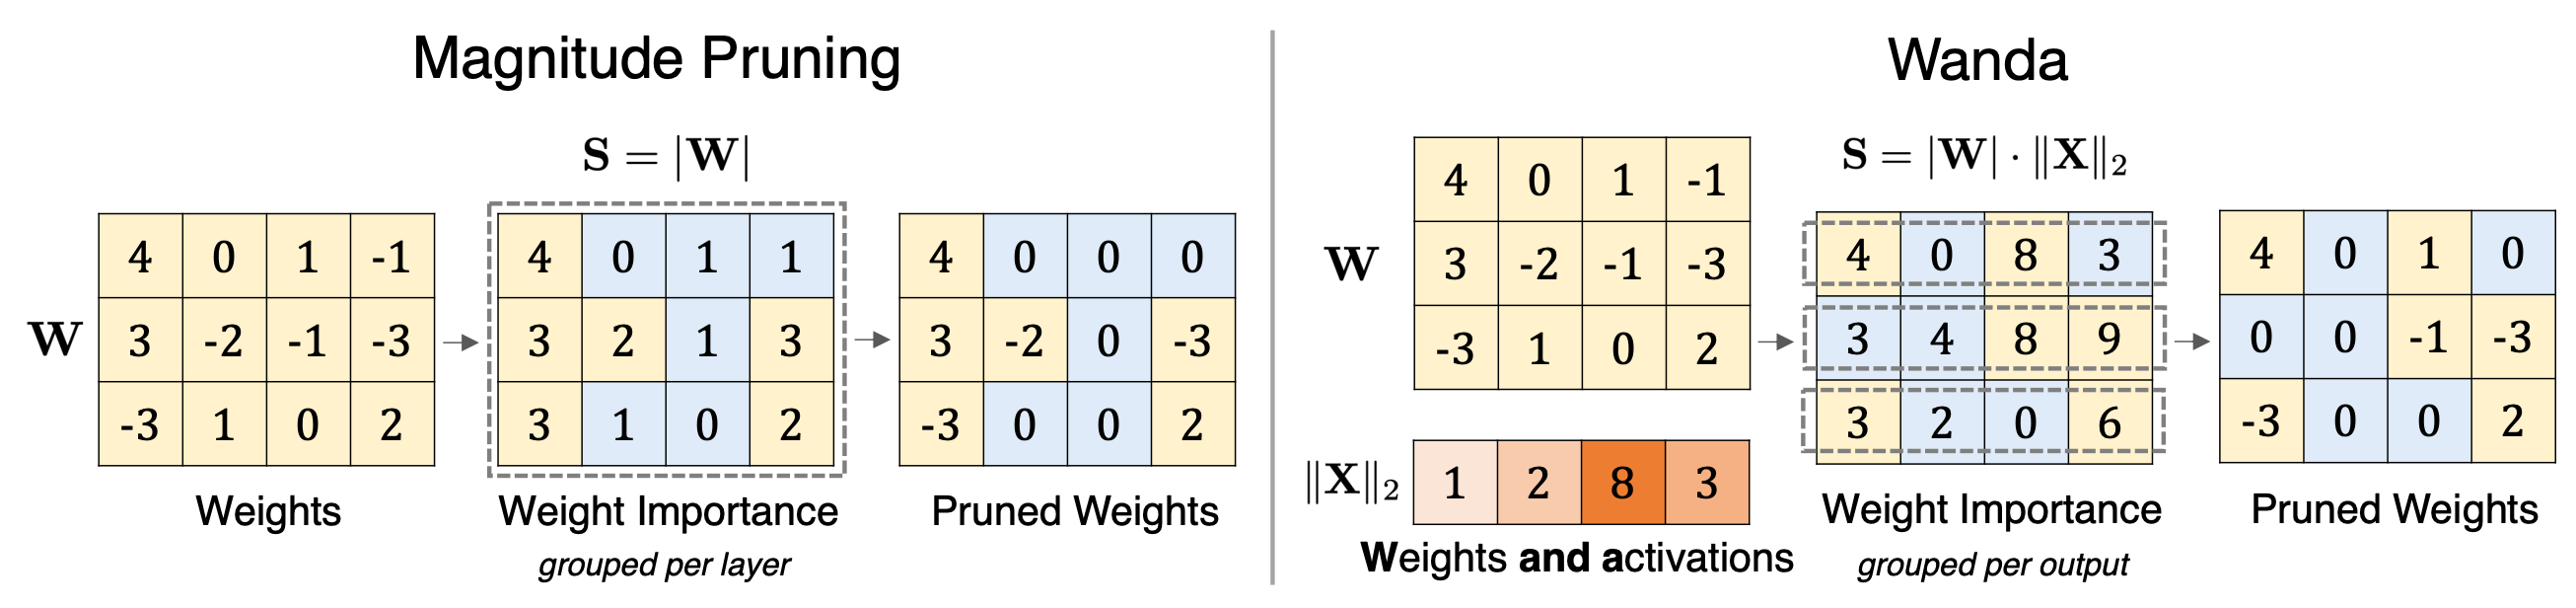

## Question 6 (15 pts)

Please finish the Wanda mask computation part in the prune function. *斜体文本*

In [30]:
class WandaPruner:
    def __init__(self, model, tokenizer, sparsity=0.5, num_samples=128):
        layers = model.model.layers
        sparsity_list = [sparsity] * len(layers)
        self.masks = self.prune(model, tokenizer, sparsity_list, num_samples)

    @torch.no_grad()
    def apply(self, model):
        print("Applying Wanda Pruning masks...")
        for name, param in model.named_parameters():
            if name in self.masks:
                param.data.mul_(self.masks[name])

    @staticmethod
    def prune(model, tokenizer, sparsity_list, num_samples=128):
        print(f"1. Wanda Calibration with {num_samples} tokens...")
        model.eval()
        act_norms = {}
        hooks = []

        # --- A. Hook Function to capture activation norms ---
        def hook_fn(module_name, module, args, output):
            inp = args[0].detach().float()
            if inp.dim() == 2: # [Batch*Seq, Hidden]
                 current_norm = inp.pow(2).sum(dim=0)
            else: # [Batch, Seq, Hidden]
                 current_norm = inp.pow(2).sum(dim=(0, 1))

            if module_name not in act_norms:
                act_norms[module_name] = current_norm
            else:
                act_norms[module_name] += current_norm

        # --- B. Register Hooks on all MLP Linear layers ---
        linear_layers = {}
        layers = model.model.layers if hasattr(model, 'model') else model.layers

        for i, layer in enumerate(layers):
            mlp = layer.mlp
            modules = {
                f"model.layers.{i}.mlp.gate_proj": mlp.gate_proj,
                f"model.layers.{i}.mlp.up_proj": mlp.up_proj,
                f"model.layers.{i}.mlp.down_proj": mlp.down_proj
            }
            for name, module in modules.items():
                linear_layers[name] = module
                hooks.append(module.register_forward_hook(partial(hook_fn, name)))

        calib_data = test_encodings.input_ids[:, :num_samples].to(model.device)

        with torch.no_grad():
            model(calib_data)
        for h in hooks: h.remove()

        print(f"2. Computing Wanda Masks...")
        masks = {}
        for name, module in linear_layers.items():
            parts = name.split('.')
            try:
                layer_idx = int(parts[parts.index('layers') + 1])
            except:
                continue

            if layer_idx >= len(sparsity_list): continue
            target_sparsity = sparsity_list[layer_idx]

            mask = None

            ##################### YOUR CODE STARTS HERE #####################
            # Wanda: importance[i,j] = |W[i,j]| * ||x_j||_2 (L2 norm of input activations)
            # Hook stores sum of squares; we need L2 norm = sqrt(sum of squares)
            param = module.weight.data
            if name in act_norms and param.dim() == 2:
                act_sq = act_norms[name].to(param.device)  # sum of squares per input dim
                act_norm = torch.sqrt(act_sq + 1e-8)       # L2 norm per input dim
                # act_norm shape (in_features,); weight shape (out_features, in_features)
                importance = param.abs() * act_norm.view(1, -1)
                mask = fine_grained_prune(importance.clone(), target_sparsity)
            else:
                mask = torch.ones_like(param, dtype=param.dtype, device=param.device)
            ##################### YOUR CODE ENDS HERE #####################
            masks[name+".weight"] = mask

        return masks

In [31]:
recover_model()
# Run the fixed function
target_sparsity = 0.6
print(f"\n=== Wanda Unstructured (Fine-Grained) @ {target_sparsity:.0%} ===")
pruner = WandaPruner(model, tokenizer, sparsity=target_sparsity, num_samples=128)
pruner.apply(model)
ppl_fg = evaluate(model)
print(f"Fine-Grained Wanda PPL: {ppl_fg:.2f}")


=== Wanda Unstructured (Fine-Grained) @ 60% ===
1. Wanda Calibration with 128 tokens...
2. Computing Wanda Masks...
Applying Wanda Pruning masks...


Evaluating PPL:   0%|          | 0/8 [00:00<?, ?it/s]

Fine-Grained Wanda PPL: 142.88


## Question 7 (10 pts)

Compare the activation-aware and weight-magnitude based pruned model before fine-tune, which one performs better? Read the paper of Wanda and briefly explain the reason.

**Your Answer:** **Activation-aware (Wanda) pruning** typically performs better than weight-magnitude-only pruning before fine-tuning. Wanda (Sun et al.) scores weights by \(|W_{ij}| \cdot \|x_j\|\) (weight magnitude times input activation norm), so it removes weights that contribute little to the forward pass. Magnitude-only pruning ignores activations and can remove weights that are small but important when activations are large. Thus Wanda yields better PPL at the same sparsity before fine-tuning.

# Channel Pruning

In this section, we will implement the channel pruning. Channel pruning removes an entire channel, so that it can achieve inference speed up on existing hardware like GPUs. Similarly, we remove the channels whose weights are of smaller magnitudes (measured by Frobenius norm).

In [32]:
# firstly, let's restore the model weights to the original dense version and check the PPL
recover_model()
dense_model_ppl = evaluate(model)
print(f"dense model has perplexity={dense_model_ppl:.2f}")
print(generate_sample_text(model, tokenizer, "Robert Boulter is an English film , television and theatre actor .", max_length=32))

Evaluating PPL:   0%|          | 0/8 [00:00<?, ?it/s]

The following generation flags are not valid and may be ignored: ['top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


dense model has perplexity=53.36
Robert Boulter is an English film , television and theatre actor . He is known for his work in the film industry, particularly in the genre of film and


## Remove Channel Weights

Unlike fine-grained pruning, we can remove the weights entirely from the tensor in channel pruning. That is to say, the number of output channels is reduced:

> $\#\mathrm{out\_channels}_{\mathrm{new}} = \#\mathrm{out\_channels}_{\mathrm{origin}} \cdot (1 - \mathrm{sparsity})$

The weight tensor $W$ is still dense after channel pruning. Thus, we will refer to *sparsity* as ***prune ratio***.

Like fine-grained pruning, we can use different pruning rates for different layers. However, we use a uniform pruning rate for all the layers for now.

## Ranking Channels by Importance

Similar to fine-grained pruning, we need to find the **less important** channel weights to remove. A popular criterion for importance is to use the Frobenius norm of the weights corresponding to each input channel:

> $importance_{i} = \|W_{i}\|_2, \;\; i = 0, 1, 2,\cdots, \#\mathrm{in\_channels}-1$

We can sort the channel weights from more important to less important, and then keep the frst $k$ channels for each layer.

## Question 8 (10 pts)

Please complete the get_magnitude_importance funtion.

In [39]:
def apply_structured_pruning(model, importance_dict, prune_ratio):
    """
    Generic function to prune based on a dictionary of importance scores.
    importance_dict: {layer_idx: tensor_of_scores_per_neuron}
    """
    pruned_model = copy.deepcopy(model)
    layers = pruned_model.model.layers
    kept_count = 0
    total_count = 0

    for i, layer in enumerate(layers):
        if i not in importance_dict: continue
        mlp = layer.mlp
        # Ensure scores on same device/dtype as weights and 1D (avoids device/dim bugs)
        w_device = mlp.gate_proj.weight.device
        scores = importance_dict[i].flatten().to(w_device)
        n_original = scores.numel()
        n_keep = int(round(n_original * (1.0 - prune_ratio)))
        if n_keep >= n_original: continue
        if scores.shape[0] != mlp.gate_proj.weight.shape[0]:
            raise ValueError(f"Layer {i}: importance length {scores.shape[0]} != intermediate size {mlp.gate_proj.weight.shape[0]}")
        _, keep_indices = torch.topk(scores, k=n_keep, sorted=False)
        keep_indices = torch.sort(keep_indices)[0].to(device=w_device).long()
        mlp.gate_proj.weight.data = mlp.gate_proj.weight.data.index_select(0, keep_indices).contiguous()
        mlp.up_proj.weight.data = mlp.up_proj.weight.data.index_select(0, keep_indices).contiguous()
        mlp.down_proj.weight.data = mlp.down_proj.weight.data.index_select(1, keep_indices).contiguous()
        if mlp.gate_proj.bias is not None:
            mlp.gate_proj.bias.data = mlp.gate_proj.bias.data.index_select(0, keep_indices).contiguous()
        if mlp.up_proj.bias is not None:
            mlp.up_proj.bias.data = mlp.up_proj.bias.data.index_select(0, keep_indices).contiguous()
        mlp.gate_proj.out_features = n_keep
        mlp.up_proj.out_features = n_keep
        mlp.down_proj.in_features = n_keep
        kept_count += n_keep
        total_count += n_original
    print(f"Pruned to {kept_count}/{total_count} neurons ({(kept_count/total_count):.1%} kept)")
    # Ensure pruned model stays on same device as original (avoids eval on wrong device)
    pruned_model = pruned_model.to(next(model.parameters()).device)
    return pruned_model

def get_magnitude_importance(model):
    importances = {}
    layers = model.model.layers if hasattr(model, 'model') else model.layers
    for i, layer in enumerate(layers):
        ##################### YOUR CODE STARTS HERE #####################
        mlp = layer.mlp
        # Frobenius (L2) norm per channel: importance_i = ||W_i||_2 (as in lab spec)
        gate_frob = mlp.gate_proj.weight.data.pow(2).sum(dim=1).sqrt()   # (intermediate,)
        up_frob = mlp.up_proj.weight.data.pow(2).sum(dim=1).sqrt()        # (intermediate,)
        down_frob = mlp.down_proj.weight.data.pow(2).sum(dim=0).sqrt()   # (intermediate,)
        importances[i] = gate_frob + up_frob + down_frob
        ##################### YOUR CODE ENDS HERE #####################
    return importances

Similar to fine-grained pruning, we can also use Wanda in structured prunning.

## Question 9 (10 pts)

Please complete Wanda importance calculation.

In [40]:
@torch.no_grad()
def get_wanda_importance(model, tokenizer, num_samples=128):
    model.eval()
    act_norms = {}
    hooks = []
    print(f"Calibrating Wanda with {num_samples} tokens...")
    def hook_fn(module, args, output):
        inp = args[0].detach().float() # [Batch, Seq, Neurons]
        if module not in act_norms:
            act_norms[module] = inp.pow(2).sum(dim=(0,1))
        else:
            act_norms[module] += inp.pow(2).sum(dim=(0,1))
    layers = model.model.layers if hasattr(model, 'model') else model.layers
    for layer in layers:
        hooks.append(layer.mlp.down_proj.register_forward_hook(hook_fn))
    calib_data = get_wikitext_data(tokenizer, "test").input_ids[:, :num_samples].to(device)
    model(calib_data)
    for h in hooks: h.remove()
    # Calculate the wanda importance scores.
    wanda_importances = {}
    for i, layer in enumerate(layers):
        ##################### YOUR CODE STARTS HERE #####################
        mlp = layer.mlp
        down_proj = mlp.down_proj
        # act_norms[down_proj] = sum of squared activations per neuron, shape (intermediate,)
        act_sq = act_norms[down_proj].to(device)
        act_norm = torch.sqrt(act_sq + 1e-8)
        gate_l1 = mlp.gate_proj.weight.data.abs().sum(dim=1)
        up_l1 = mlp.up_proj.weight.data.abs().sum(dim=1)
        down_l1 = mlp.down_proj.weight.data.abs().sum(dim=0)
        wanda_importances[i] = act_norm * (gate_l1 + up_l1 + down_l1)
        ##################### YOUR CODE ENDS HERE #####################
    return wanda_importances

Run the following cell to test your implementation.

In [41]:
target_sparsity = 0.30
print("\n--- 1. Magnitude Pruning ---")
mag_scores = get_magnitude_importance(model)
model_mag = apply_structured_pruning(model, mag_scores, target_sparsity)
ppl_mag = evaluate(model_mag)
print(f"Magnitude Pruning PPL: {ppl_mag:.2f}")
del model_mag

print("\n--- 2. Wanda (Activation-Aware) Pruning ---")
wanda_scores = get_wanda_importance(model, tokenizer)
model_wanda = apply_structured_pruning(model, wanda_scores, target_sparsity)
ppl_wanda = evaluate(model_wanda)
print(f"Wanda Pruning PPL:     {ppl_wanda:.2f}")

print(f"\nSummary (Sparsity {target_sparsity:.0%}):")
print(f"Magnitude PPL: {ppl_mag:.2f}")
print(f"Wanda PPL:       {ppl_wanda:.2f}")


--- 1. Magnitude Pruning ---
Pruned to 25812/36864 neurons (70.0% kept)


Evaluating PPL:   0%|          | 0/8 [00:00<?, ?it/s]

Magnitude Pruning PPL: 6312631992320.00

--- 2. Wanda (Activation-Aware) Pruning ---
Calibrating Wanda with 128 tokens...
Pruned to 25812/36864 neurons (70.0% kept)


Evaluating PPL:   0%|          | 0/8 [00:00<?, ?it/s]

Wanda Pruning PPL:     84.39

Summary (Sparsity 30%):
Magnitude PPL: 6312631992320.00
Wanda PPL:       84.39


Now let's evaluate the number of MAC operations of the FFN layer after pruning with 30% pruning rate.

As you may see, directly removing 30% of the channels leads 30% reduction of MAC operarions.

In [42]:
batch_size = 1
seq_len = 1024
hidden_size = model.config.hidden_size

dummy_input = torch.randn(batch_size, seq_len, hidden_size, dtype=torch.float32, device=device)
dense_macs = get_model_macs(model.model.layers[0].mlp, dummy_input)
print(f"Dense FFN MACs: {dense_macs}")
pruned_macs = get_model_macs(model_wanda.model.layers[0].mlp, dummy_input)
print(f"Pruned FFN MACs: {pruned_macs}")
print(f"Reduction: {(dense_macs - pruned_macs) / dense_macs:.2f}")

Dense FFN MACs: 4028628992
Pruned FFN MACs: 2820827136
Reduction: 0.30


Wanda structured pruned model is much better than magnitude structured pruned model. So we will use the Wanda model for later experiment. Let's check the sample generation of it.

In [43]:
print(generate_sample_text(model_wanda, tokenizer, "Robert Boulter is an English film , television and theatre actor .", max_length=32))

Robert Boulter is an English film , television and theatre actor . He has been a successful actor in the past, and has been a successful actor in the


As you can see, it performs well on generation. But the PPL we got is still higher than the dense model. Fortunately, we can fine-tune it to recover the PPL.

In [44]:
recovered_model = train(model_wanda, tokenizer, pruner=None, num_steps=25, lr=1e-4)
print(evaluate(recovered_model))
print(generate_sample_text(recovered_model, tokenizer, "Robert Boulter is an English film , television and theatre actor .", max_length=32))


Training for 25 steps to recover performance...


Training:   0%|          | 0/25 [00:00<?, ?it/s]

Evaluating PPL:   0%|          | 0/8 [00:00<?, ?it/s]

41.94060516357422
Robert Boulter is an English film , television and theatre actor . He was originally directed by Robert Williams and directed by Robert Williams . He was also directed by


## Measure acceleration from pruning

After fine-tuning, the model recovers the perplexity. You may have already learned that channel pruning is usually more difficult to recover perplexity compared to fine-grained pruning. However, it directly leads to a smaller model size and smaller computation without specialized model format. It can also run faster on GPUs. Now we compare the model size, computation, and latency of the pruned model.

In [45]:
@torch.no_grad()
def measure_latency(module, dummy_input, n_warmup=20, n_test=100):
    module.eval()
    # Warmup
    for _ in range(n_warmup):
        _ = module(dummy_input)

    # Synchronize before timing (Critical for GPU)
    if torch.cuda.is_available():
        torch.cuda.synchronize()

    # Measurement
    t1 = time.time()
    for _ in range(n_test):
        _ = module(dummy_input)

    # Synchronize after timing
    if torch.cuda.is_available():
        torch.cuda.synchronize()

    t2 = time.time()
    return (t2 - t1) / n_test

# 1. Setup Data & Modules
layer_idx = 2 # Using layer 2 as representative
print(f"Benchmarking MLP (Layer {layer_idx})")

# Extract MLPs
mlp_original = copy.deepcopy(model.model.layers[layer_idx].mlp).to(device)
mlp_pruned = copy.deepcopy(recovered_model.model.layers[layer_idx].mlp).to(device)

for module in mlp_pruned.modules():
    if isinstance(module, nn.Linear):
        module.weight.data = module.weight.data.contiguous()

hidden_size = model.config.hidden_size
dummy_input = torch.randn(128, 128, hidden_size).to(device)

# 2. Run Benchmarks
table_template = "{:<20} {:<15} {:<15} {:<15}"
print("-" * 70)
print(table_template.format('Metric', 'Original', 'Pruned', 'Reduction'))
print("-" * 70)

# A. Latency
lat_orig = measure_latency(mlp_original, dummy_input)
lat_pruned = measure_latency(mlp_pruned, dummy_input)
print(table_template.format(
    'Latency (ms)',
    f"{lat_orig*1000:.3f}",
    f"{lat_pruned*1000:.3f}",
    f"{(lat_orig - lat_pruned)/lat_orig:.2%}"
))

# B. MACs
macs_orig = get_model_macs(mlp_original, dummy_input)
macs_pruned = get_model_macs(mlp_pruned, dummy_input)
print(table_template.format(
    'MACs (M)',
    f"{macs_orig/1e6:.2f}",
    f"{macs_pruned/1e6:.2f}",
    f"{1 - macs_pruned/macs_orig:.2%}"
))

# C. Parameters
params_orig = get_num_parameters(mlp_original)
params_pruned = get_num_parameters(mlp_pruned)
print(table_template.format(
    'Params (M)',
    f"{params_orig/1e6:.2f}",
    f"{params_pruned/1e6:.2f}",
    f"{1 - params_pruned/params_orig:.2%}"
))
print("-" * 70)

Benchmarking MLP (Layer 2)
----------------------------------------------------------------------
Metric               Original        Pruned          Reduction      
----------------------------------------------------------------------
Latency (ms)         36.921          24.801          32.83%         
MACs (M)             64458.06        45133.23        29.98%         
Params (M)           3.93            2.75            29.98%         
----------------------------------------------------------------------


## Question 10 (5 pts)

Explain why the latency reduction ratio is slightly smaller than computation reduction.


**Your Answer:** **Latency reduction is often slightly smaller than computation (MAC) reduction** because: (1) **Memory bandwidth**—pruned models still load full weight tensors from memory unless the hardware stores and loads only nonzeros; (2) **irregular access**—fine-grained sparsity can cause scattered memory access and lower GPU utilization; (3) **overhead**—sparse kernels have indexing/control overhead. So FLOPs/MACs drop more than actual runtime unless using hardware optimized for the given sparsity pattern.

# Compare Fine-grained Pruning and Channel Pruning


## Question 11 (10 pts)


After all experiments in this lab, you may have become familiar with both fine-grained pruning and channel pruning.

Please answer the following questions using what you have learned from the lectures and this lab.

### Question 11.1 (5 pts)

What are the advantages and disadvantages of fine-grained pruning and channel pruning? You can discuss from the perspective of compression ratio, perplexity (performance), latency, hardware support (*i.e.*, requiring specialized hardware accelerator), etc.

**Your Answer:** **Fine-grained pruning:** Advantages—high compression ratio (many zeros), no change to layer dimensions (easy drop-in). Disadvantages—irregular sparsity often needs specialized hardware/software for real speedup; latency reduction can be less than FLOP reduction. **Channel pruning:** Advantages—regular structure (fewer channels), easy speedup on standard hardware, latency reduction closer to FLOP reduction. Disadvantages—lower compression ratio for same accuracy drop; changes shapes so may need extra handling. Tradeoff: fine-grained wins on size and flexibility; channel pruning wins on deployability and predictable speedup.

### Question 11.2 (5 pts)

If you want to make your model run faster on a smartphone, which pruning method will you use? Why?

**Your Answer:** **Channel pruning** is the better choice for faster inference on a smartphone. Smartphones typically use CPUs or standard mobile GPUs with no (or limited) support for sparse matrix ops, so fine-grained pruning often does not translate to real latency gains. Channel pruning reduces dimensions and FLOPs in a regular way, so existing frameworks (e.g. ONNX, TFLite) can run the model faster without custom kernels. The smaller, dense matrices also fit mobile memory and cache better.